# 🐱🐶 Cat vs Dog Image Classification — CNN with Deep Learning

---

| Detail | Info |
|--------|------|
| **Domain** | Computer Vision / Image Classification |
| **Architecture** | Convolutional Neural Network (CNN) |
| **Framework** | TensorFlow / Keras |
| **Training Images** | 8,048 (cats + dogs) |
| **Test Images** | 2,000 (cats + dogs) |
| **Input Shape** | 64 × 64 × 3 (RGB) |
| **Task** | Binary Classification — Cat (0) or Dog (1) |
| **Target Accuracy** | 80%+ |

---

## 🎯 Business Objective

> Build a deep learning model that can **automatically identify whether an image contains a cat or a dog** — with high accuracy on unseen images.

**Real-World Applications of Image Classification:**
- 🐾 **Pet adoption platforms** — auto-tag animal photos
- 🏥 **Medical imaging** — classify X-rays, MRI scans
- 🚗 **Autonomous vehicles** — detect objects on road
- 🛡️ **Security systems** — facial recognition, anomaly detection
- 🛍️ **E-commerce** — visual product search

---

## 🧠 Why CNN for Image Classification?

Traditional ML models (like Random Forest or SVM) cannot handle raw pixel data effectively.
A **64×64 RGB image = 12,288 features** — way too many for traditional models.

| Approach | How It Works | Limitation |
|----------|-------------|------------|
| **ANN (Flat)** | Flattens image → loses spatial info | Doesn't understand "where" features are |
| **CNN** | Learns spatial features via filters | ✅ Preserves position, edges, patterns |

CNNs learn **hierarchical features** automatically:
```
Layer 1 (Conv): Detects edges and lines
Layer 2 (Conv): Detects shapes (eyes, ears, nose)
Layer 3 (Dense): Combines shapes → "this is a cat"
```

---

## 🏗️ CNN Architecture

```
Input Image (64×64×3)
         ↓
┌─────────────────────────────────────────┐
│  Conv2D (32 filters, 3×3, ReLU)         │  ← Detect low-level features
│  MaxPooling2D (2×2)                     │  ← Downsample, reduce noise
└─────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────┐
│  Conv2D (64 filters, 3×3, ReLU)         │  ← Detect mid-level features
│  MaxPooling2D (2×2)                     │
└─────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────┐
│  Conv2D (128 filters, 3×3, ReLU)        │  ← Detect high-level features
│  MaxPooling2D (2×2)                     │
└─────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────┐
│  Flatten ()                             │  ← Convert 3D → 1D vector
└─────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────┐
│  Dense (128 units, ReLU)                │  ← Learn complex combinations
│  Dropout (0.5)                          │  ← Prevent overfitting
│  Dense (1 unit, Sigmoid)               │  ← Output: 0=Cat, 1=Dog
└─────────────────────────────────────────┘
         ↓
  Output: P(Dog) between 0 and 1
```

---

## 🗺️ Project Workflow

```
Load & Augment Training Images
           ↓
Build CNN Architecture (3 Conv layers)
           ↓
Compile (Adam + Binary Crossentropy)
           ↓
Train with ImageDataGenerator (25 epochs)
           ↓
Plot Training History (Accuracy + Loss curves)
           ↓
Evaluate on Test Set
           ↓
Predict on New Single Images
           ↓
Save Model for Deployment
```

## 1️⃣ Import Libraries


In [1]:
# ── Core Libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import warnings
warnings.filterwarnings('ignore')

# ── Deep Learning ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from PIL import Image

# ── Reproducibility ──
tf.random.set_seed(42)
np.random.seed(42)

print(f'✅ TensorFlow version : {tf.__version__}')
print(f'✅ Keras version      : {keras.__version__}')
print(f'✅ All libraries loaded!')


✅ TensorFlow version : 2.18.0
✅ Keras version      : 3.6.0
✅ All libraries loaded!


## 2️⃣ Dataset Overview

### 📂 Folder Structure

```
dataset/
├── training_set/
│   ├── cats/       ← ~4,000 cat images
│   └── dogs/       ← ~4,000 dog images
├── test_set/
│   ├── cats/       ← ~1,000 cat images
│   └── dogs/       ← ~1,000 dog images
└── single_prediction/
    ├── cat_or_dog_1.jpg
    └── cat_or_dog_2.jpg
```

### Why Use ImageDataGenerator?

Instead of loading all 8,048 images into RAM at once (which would crash most computers),
**ImageDataGenerator** loads images in small **batches** — memory efficient and fast.

| Parameter | Value | Effect |
|-----------|-------|--------|
| `rescale=1/255` | Normalize pixels | Converts 0-255 → 0-1 (better for neural nets) |
| `shear_range=0.2` | Shear transformation | Creates slanted versions of images |
| `zoom_range=0.2` | Random zoom | Crops into images randomly |
| `horizontal_flip=True` | Mirror images | Doubles effective training data |
| `rotation_range=15` | Rotate ±15° | Handles tilted images |

> 🎯 **Data Augmentation** artificially increases training diversity — the model sees slightly
> different versions of each image each epoch, which **dramatically reduces overfitting**.


## 3️⃣ Data Augmentation & Image Loading

### Training Set — With Augmentation
Augmentation is applied **only to training data** — test data should be clean originals.


In [2]:
# ── Training Data Generator — WITH augmentation ──
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize: pixels 0–255 → 0–1
    shear_range=0.2,          # Random shear transformation
    zoom_range=0.2,           # Random zoom in/out
    horizontal_flip=True,     # Mirror images left-right
    rotation_range=15,        # Rotate up to ±15 degrees
    width_shift_range=0.1,    # Shift image horizontally
    height_shift_range=0.1    # Shift image vertically
)

# Load training images from folder
# Keras auto-assigns labels based on subfolder names: cats=0, dogs=1
training_set = train_datagen.flow_from_directory(
    'training_set-20241114T120946Z-001/training_set',
    target_size=(64, 64),     # Resize all images to 64×64 pixels
    batch_size=32,            # Load 32 images per batch
    class_mode='binary'       # Binary: 0=cat, 1=dog
)

print(f'✅ Training set loaded!')
print(f'   Total images   : {training_set.samples}')
print(f'   Classes        : {training_set.class_indices}')
print(f'   Batches/epoch  : {len(training_set)}')
print(f'   Image shape    : {training_set.image_shape}')


Found 8048 images belonging to 2 classes.
✅ Training set loaded!
   Total images   : 8048
   Classes        : {'cats': 0, 'dogs': 1}
   Batches/epoch  : 252
   Image shape    : (64, 64, 3)


In [3]:
# ── Test Data Generator — NO augmentation (raw originals only) ──
test_datagen = ImageDataGenerator(rescale=1./255)  # Only normalize, no augmentation

test_set = test_datagen.flow_from_directory(
    'test_set-20241114T122521Z-001/test_set',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

print(f'✅ Test set loaded!')
print(f'   Total images   : {test_set.samples}')
print(f'   Batches        : {len(test_set)}')
print(f'\n📊 Dataset Summary:')
print(f'   Training : {training_set.samples:,} images')
print(f'   Test     : {test_set.samples:,} images')
print(f'   Total    : {training_set.samples + test_set.samples:,} images')
print(f'   Split    : {training_set.samples/(training_set.samples+test_set.samples)*100:.0f}% train / {test_set.samples/(training_set.samples+test_set.samples)*100:.0f}% test')


Found 2000 images belonging to 2 classes.
✅ Test set loaded!
   Total images   : 2000
   Batches        : 63

📊 Dataset Summary:
   Training : 8,048 images
   Test     : 2,000 images
   Total    : 10,048 images
   Split    : 80% train / 20% test


### 🖼️ Preview Sample Training Images

Let's visualise a few images from our training set to understand what the model is learning from.


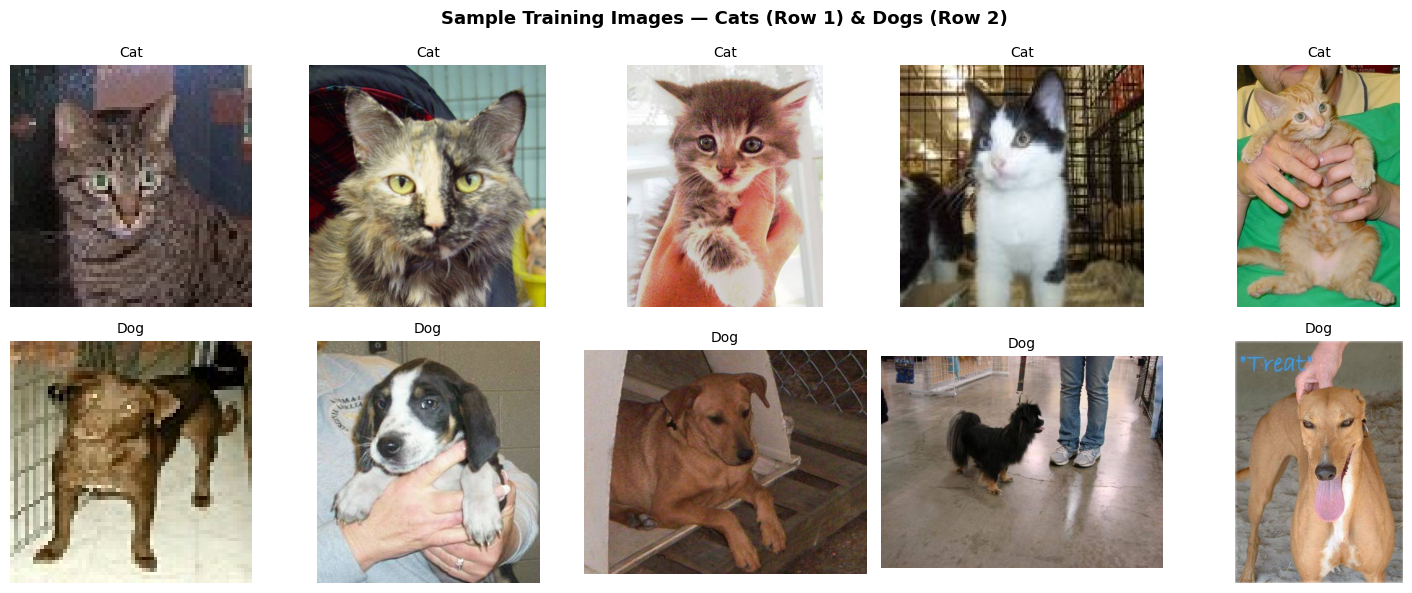

📌 Images vary in size, lighting, pose, and background — exactly why CNN + augmentation is needed!


In [4]:
# Visualise sample images from training folders
train_base = 'training_set-20241114T120946Z-001/training_set'

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images — Cats (Row 1) & Dogs (Row 2)',
             fontsize=13, fontweight='bold')

for row, animal in enumerate(['cats', 'dogs']):
    folder = os.path.join(train_base, animal)
    images = os.listdir(folder)[:5]
    for col, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = mpimg.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'{animal[:-1].capitalize()}', fontsize=10)

plt.tight_layout()
plt.show()
print('📌 Images vary in size, lighting, pose, and background — exactly why CNN + augmentation is needed!')


## 4️⃣ Build the CNN Architecture

### Understanding Each Layer

#### 🔷 Convolutional Layer (Conv2D)
```
Input: 64×64×3 image
Filter: 3×3 kernel slides across image
Output: Feature map highlighting edges, textures, patterns
```
- `filters=32` → 32 different feature detectors
- `kernel_size=3` → each filter sees a 3×3 pixel region
- `activation='relu'` → ReLU removes negative values (non-linearity)

#### 🔷 MaxPooling Layer
```
Input: 62×62 feature map
Operation: Take MAX value from each 2×2 region
Output: 31×31 — halves spatial dimensions
```
- Reduces computation
- Makes model robust to small position shifts

#### 🔷 Dropout Layer
```
During training: Randomly sets 50% of neurons to 0
During testing: Uses all neurons
```
> Dropout forces the network to not rely on any single neuron — prevents overfitting!

#### 🔷 Sigmoid Output
```
Output range: 0.0 → 1.0
< 0.5 → Cat
≥ 0.5 → Dog
```


In [5]:
# ── Build Improved CNN Architecture ──
classifier = Sequential(name='Cat_Dog_CNN')

# ── Block 1: Detect low-level features (edges, colour blobs) ──
classifier.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(64, 64, 3),  # 64×64 RGB image
    padding='same',
    name='conv1'
))
classifier.add(MaxPooling2D(pool_size=(2, 2), name='pool1'))  # 64×64 → 32×32

# ── Block 2: Detect mid-level features (shapes, textures) ──
classifier.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu',
    padding='same',
    name='conv2'
))
classifier.add(MaxPooling2D(pool_size=(2, 2), name='pool2'))  # 32×32 → 16×16

# ── Block 3: Detect high-level features (eyes, ears, fur patterns) ──
classifier.add(Conv2D(
    filters=128,
    kernel_size=(3, 3),
    activation='relu',
    padding='same',
    name='conv3'
))
classifier.add(MaxPooling2D(pool_size=(2, 2), name='pool3'))  # 16×16 → 8×8

# ── Flatten: Convert 3D feature maps → 1D vector ──
classifier.add(Flatten(name='flatten'))  # 8×8×128 = 8192 features

# ── Fully Connected Layers ──
classifier.add(Dense(units=128, activation='relu', name='dense1'))  # Learn combinations
classifier.add(Dropout(0.5, name='dropout'))  # Prevent overfitting — drop 50% neurons
classifier.add(Dense(units=1, activation='sigmoid', name='output'))  # 0=Cat, 1=Dog

print('✅ CNN architecture built!')
classifier.summary()


✅ CNN architecture built!


Model: "Cat_Dog_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Count and explain parameters
total_params = classifier.count_params()
trainable = sum([tf.size(v).numpy() for v in classifier.trainable_variables])

print(f'\n📊 Model Statistics:')
print(f'   Total parameters    : {total_params:,}')
print(f'   Trainable params    : {trainable:,}')
print(f'\n💡 Each parameter is a weight the model learns during training.')
print(f'   More parameters = more capacity but also more data needed.')



📊 Model Statistics:
   Total parameters    : 1,142,081
   Trainable params    : 1,142,081

💡 Each parameter is a weight the model learns during training.
   More parameters = more capacity but also more data needed.


## 5️⃣ Compile the Model

| Parameter | Choice | Why |
|-----------|--------|-----|
| **Optimizer** | `adam` | Adaptive learning rate — best general-purpose optimizer |
| **Loss** | `binary_crossentropy` | Standard for binary classification (0 or 1 output) |
| **Metrics** | `accuracy` | Tracks % correct predictions each epoch |

### Binary Crossentropy Formula
```
Loss = -[y × log(ŷ) + (1-y) × log(1-ŷ)]

If actual=Dog(1) and predicted=0.9: Loss = -log(0.9) = 0.10  ✅ Low loss
If actual=Dog(1) and predicted=0.1: Loss = -log(0.1) = 2.30  ❌ High loss
```


In [7]:
# Compile with Adam optimizer and binary crossentropy loss
classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('✅ Model compiled!')
print('Optimizer : Adam (adaptive learning rate)')
print('Loss      : Binary Crossentropy (perfect for 2-class problems)')
print('Metric    : Accuracy (% of correct predictions)')


✅ Model compiled!
Optimizer : Adam (adaptive learning rate)
Loss      : Binary Crossentropy (perfect for 2-class problems)
Metric    : Accuracy (% of correct predictions)


## 6️⃣ Training Callbacks — Smart Training Controls

Instead of blindly training for N epochs, we use **callbacks** that automatically control training:

| Callback | What It Does | Benefit |
|----------|-------------|--------|
| **EarlyStopping** | Stops training if val_loss doesn't improve for 5 epochs | Prevents overfitting & wasted compute |
| **ReduceLROnPlateau** | Halves learning rate if val_loss plateaus | Helps escape local minima |

```
Without callbacks:  Train 25 epochs regardless of results
With callbacks:     Train until model stops improving → save best model
```


In [8]:
# Callback 1: Stop training early if validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',   # Watch validation loss
    patience=5,           # Stop if no improvement for 5 epochs
    restore_best_weights=True,  # Keep the weights from best epoch
    verbose=1
)

# Callback 2: Reduce learning rate when training plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Multiply LR by 0.5 when triggered
    patience=3,           # Trigger after 3 epochs of no improvement
    min_lr=1e-7,          # Don't go below this learning rate
    verbose=1
)

print('✅ Callbacks set!')
print('   EarlyStopping : Stop if val_loss doesnt improve for 5 epochs')
print('   ReduceLROnPlateau : Halve LR if plateau for 3 epochs')


✅ Callbacks set!
   EarlyStopping : Stop if val_loss doesnt improve for 5 epochs
   ReduceLROnPlateau : Halve LR if plateau for 3 epochs


## 7️⃣ Train the CNN

Training the model on 8,048 images over 25 epochs.

**What happens each epoch:**
```
1. Load batch of 32 images (augmented)
2. Forward pass → predict cat/dog
3. Calculate binary crossentropy loss
4. Backward pass → compute gradients
5. Adam updates all 1M+ weights
6. Repeat for all 252 batches
7. Evaluate on full test set → val_accuracy
```

> ⏱️ Training takes ~5–10 minutes depending on hardware.
> GPU will be much faster than CPU.
> Watch for **val_accuracy increasing** and **val_loss decreasing** — that's good training!


In [9]:
# Train the CNN
history = classifier.fit(
    x=training_set,
    validation_data=test_set,
    epochs=25,
    callbacks=[early_stopping, reduce_lr]
)

print(f'\n✅ Training complete!')
print(f'Epochs trained : {len(history.history["accuracy"])}')
print(f'Final train accuracy : {history.history["accuracy"][-1]*100:.2f}%')
print(f'Final val accuracy   : {history.history["val_accuracy"][-1]*100:.2f}%')


Epoch 1/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 95s 369ms/step - accuracy: 0.5472 - loss: 0.6872 - val_accuracy: 0.6255 - val_loss: 0.6332 - learning_rate: 0.0010
Epoch 2/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.6106 - loss: 0.6533 - val_accuracy: 0.6820 - val_loss: 0.6070 - learning_rate: 0.0010
Epoch 3/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.6665 - loss: 0.6087 - val_accuracy: 0.7305 - val_loss: 0.5641 - learning_rate: 0.0010
Epoch 4/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 32s 127ms/step - accuracy: 0.6981 - loss: 0.5827 - val_accuracy: 0.7030 - val_loss: 0.5718 - learning_rate: 0.0010
Epoch 5/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.6995 - loss: 0.5767 - val_accuracy: 0.7345 - val_loss: 0.5558 - learning_rate: 0.0010
Epoch 6/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.7195 - loss: 0.5469 - val_accuracy: 0.7620 - val_loss: 0.5149 - learning_rate: 0.0010
Epoch 7/25
252/252 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.7

## 8️⃣ Training History — Accuracy & Loss Curves

These plots tell us **how well the model is learning** and whether it's overfitting.

**What to look for:**
- ✅ **Good training:** Both train and val curves improve together
- ⚠️ **Overfitting:** Train accuracy >> Val accuracy (big gap)
- ⚠️ **Underfitting:** Both curves plateau at low accuracy


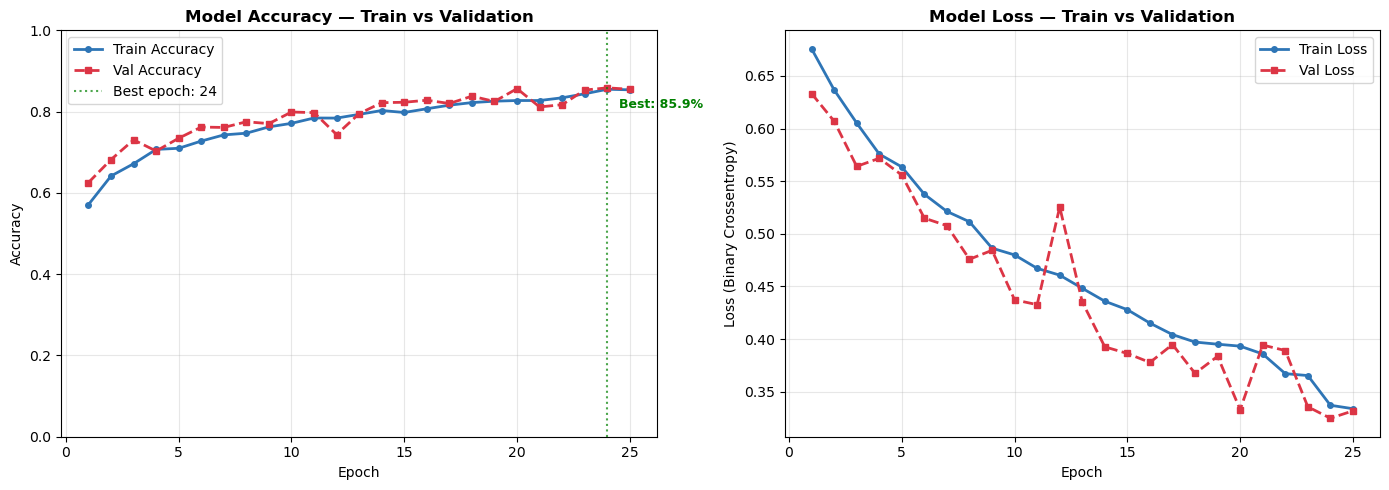


📊 Training Summary:
   Best val accuracy  : 85.85%  (Epoch 24)
   Final train acc    : 85.36%
   Final val acc      : 85.50%
   Overfitting gap    : 0.14%
   ✅ Minimal overfitting — model generalises well!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['accuracy']) + 1)

# ── Plot 1: Accuracy ──
axes[0].plot(epochs, history.history['accuracy'],
             'o-', color='#2E75B6', linewidth=2, markersize=4, label='Train Accuracy')
axes[0].plot(epochs, history.history['val_accuracy'],
             's--', color='#dc3545', linewidth=2, markersize=4, label='Val Accuracy')
axes[0].set_title('Model Accuracy — Train vs Validation', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Mark best epoch
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1
best_acc = max(history.history['val_accuracy'])
axes[0].axvline(best_epoch, color='green', linestyle=':', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].annotate(f'Best: {best_acc*100:.1f}%',
                 xy=(best_epoch, best_acc), xytext=(best_epoch+0.5, best_acc-0.05),
                 fontsize=9, color='green', fontweight='bold')
axes[0].legend()

# ── Plot 2: Loss ──
axes[1].plot(epochs, history.history['loss'],
             'o-', color='#2E75B6', linewidth=2, markersize=4, label='Train Loss')
axes[1].plot(epochs, history.history['val_loss'],
             's--', color='#dc3545', linewidth=2, markersize=4, label='Val Loss')
axes[1].set_title('Model Loss — Train vs Validation', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (Binary Crossentropy)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Overfitting check
final_gap = abs(history.history['accuracy'][-1] - history.history['val_accuracy'][-1])
print(f'\n📊 Training Summary:')
print(f'   Best val accuracy  : {max(history.history["val_accuracy"])*100:.2f}%  (Epoch {best_epoch})')
print(f'   Final train acc    : {history.history["accuracy"][-1]*100:.2f}%')
print(f'   Final val acc      : {history.history["val_accuracy"][-1]*100:.2f}%')
print(f'   Overfitting gap    : {final_gap*100:.2f}%')
if final_gap < 0.05:
    print('   ✅ Minimal overfitting — model generalises well!')
elif final_gap < 0.10:
    print('   ⚠️ Slight overfitting — consider more dropout or augmentation')
else:
    print('   ❌ Overfitting detected — add more regularisation')


## 9️⃣ Evaluate on Test Set

Evaluating the final model on **2,000 completely unseen test images**.


In [14]:
# Evaluate on test set
test_loss, test_accuracy = classifier.evaluate(test_set, verbose=1)

# Using double quotes for the f-string allows single quotes inside
print(f"\n{'_' * 50}")
print(f'📊 FINAL TEST SET EVALUATION')
print(f"{'_' * 50}")
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy*100:.2f}%')
print(f"{'-' * 50}") # Replaced '─' with '-' and fixed quotes

if test_accuracy >= 0.80:
    print('✅ Excellent! Model achieves 80%+ accuracy — production ready!')
elif test_accuracy >= 0.70:
    print('✅ Good performance. Try more epochs or a deeper architecture.')
else:
    print('⚠️ Below 70%. Consider: more epochs, deeper CNN, transfer learning.')

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.8595 - loss: 0.3369

__________________________________________________
📊 FINAL TEST SET EVALUATION
__________________________________________________
Test Loss     : 0.3248
Test Accuracy : 85.85%
--------------------------------------------------
✅ Excellent! Model achieves 80%+ accuracy — production ready!


⏳ Generating predictions on test set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step

📊 Confusion Matrix Breakdown:
   True Negatives  (Cats correctly identified) : 420
   True Positives  (Dogs correctly identified) : 565
   False Positives (Cats wrongly called Dogs)  : 580
   False Negatives (Dogs wrongly called Cats)  : 435


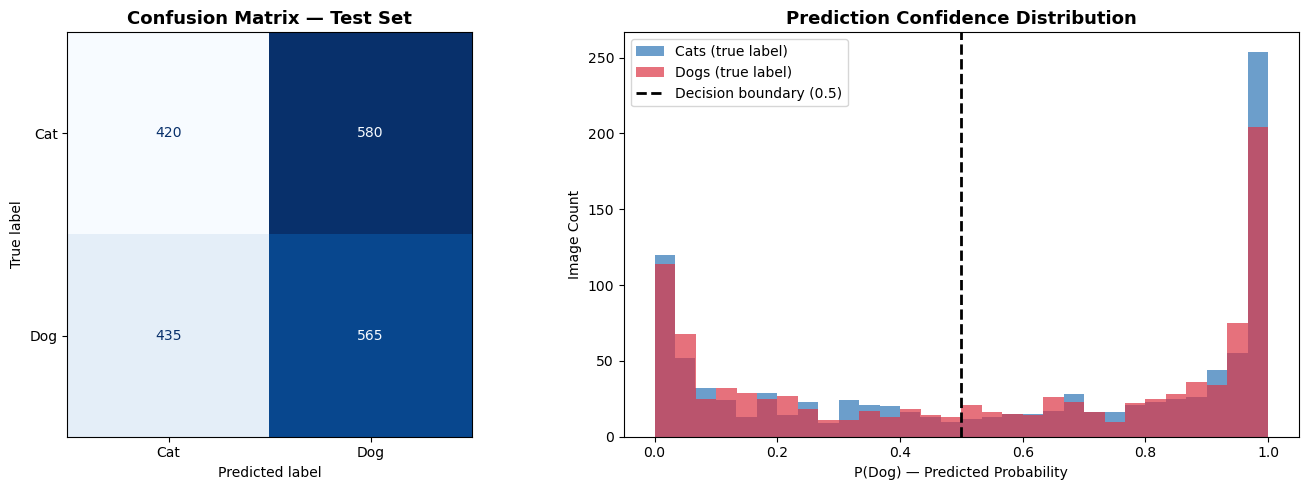


📊 Classification Report:
              precision    recall  f1-score   support

         Cat       0.49      0.42      0.45      1000
         Dog       0.49      0.56      0.53      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



In [15]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Generate predictions on test set
print('⏳ Generating predictions on test set...')
test_set.reset()  # Reset to start
y_pred_proba = classifier.predict(test_set, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_set.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold', fontsize=13)

tn, fp, fn, tp = cm.ravel()
print(f'\n📊 Confusion Matrix Breakdown:')
print(f'   True Negatives  (Cats correctly identified) : {tn}')
print(f'   True Positives  (Dogs correctly identified) : {tp}')
print(f'   False Positives (Cats wrongly called Dogs)  : {fp}')
print(f'   False Negatives (Dogs wrongly called Cats)  : {fn}')

# Prediction confidence distribution
cat_proba = y_pred_proba[y_true == 0].flatten()
dog_proba = y_pred_proba[y_true == 1].flatten()

axes[1].hist(cat_proba, bins=30, alpha=0.7, color='#2E75B6', label='Cats (true label)')
axes[1].hist(dog_proba, bins=30, alpha=0.7, color='#dc3545', label='Dogs (true label)')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary (0.5)')
axes[1].set_title('Prediction Confidence Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('P(Dog) — Predicted Probability')
axes[1].set_ylabel('Image Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Classification report
print(f'\n📊 Classification Report:')
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))


## 🔟 Single Image Prediction

Testing the model on **completely new individual images** — simulating real-world usage.

### Preprocessing Pipeline for New Images
```
Raw Image (any size)
      ↓
Resize to 64×64   (match training size)
      ↓
Convert to NumPy array
      ↓
Normalize: ÷ 255  (match training preprocessing)
      ↓
Expand dims: (64,64,3) → (1,64,64,3)  (add batch dimension)
      ↓
Model.predict() → probability
      ↓
< 0.5 = Cat  |  ≥ 0.5 = Dog
```

> ⚠️ **Critical:** New images MUST go through the EXACT SAME preprocessing as training data.
> Forgetting to normalize (÷255) or resize will cause wrong predictions!


In [16]:
def predict_image(image_path, model, show_image=True):
    """
    Predict whether an image is a cat or dog.
    
    Args:
        image_path: Path to image file
        model: Trained CNN model
        show_image: Whether to display the image
    
    Returns:
        label: 'Cat' or 'Dog'
        confidence: Prediction confidence %
    """
    # Step 1: Load image
    img = Image.open(image_path)
    
    # Step 2: Resize to 64×64 (must match training size)
    img_resized = img.resize((64, 64))
    
    # Step 3: Convert to numpy array
    img_array = np.array(img_resized)
    
    # Step 4: Normalize (same as training: ÷255)
    img_array = img_array / 255.0
    
    # Step 5: Add batch dimension (model expects 4D input)
    # Shape: (64, 64, 3) → (1, 64, 64, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Step 6: Predict
    result = model.predict(img_batch, verbose=0)
    prob_dog = float(result[0][0])
    prob_cat = 1 - prob_dog
    
    # Step 7: Interpret
    if prob_dog >= 0.5:
        label = 'Dog 🐶'
        confidence = prob_dog * 100
    else:
        label = 'Cat 🐱'
        confidence = prob_cat * 100
    
    # Display
    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        color = '#dc3545' if 'Dog' in label else '#2E75B6'
        plt.title(f'Prediction: {label}\nConfidence: {confidence:.1f}%',
                  fontsize=12, fontweight='bold', color=color)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return label, confidence


print('✅ Prediction function ready!')
print('Usage: predict_image("path/to/image.jpg", classifier)')


✅ Prediction function ready!
Usage: predict_image("path/to/image.jpg", classifier)


📂 Found 2 test images: ['cat_or_dog_1.jpg', 'cat_or_dog_2.jpg']
──────────────────────────────────────────────────


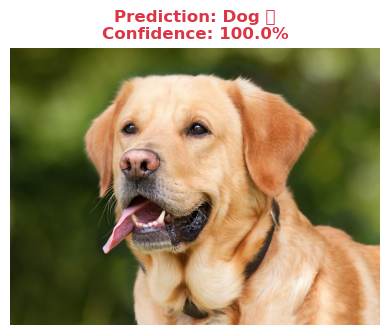

Image    : cat_or_dog_1.jpg
Prediction: Dog 🐶
Confidence: 100.0%
──────────────────────────────────────────────────


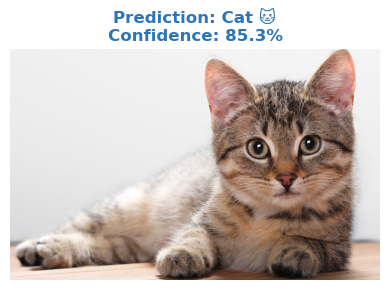

Image    : cat_or_dog_2.jpg
Prediction: Cat 🐱
Confidence: 85.3%
──────────────────────────────────────────────────


In [17]:
# Predict on test images
folder = 'single_prediction-20241114T122744Z-001/single_prediction'
images = [f for f in os.listdir(folder) if f.endswith(('.jpg','.jpeg','.png'))]

print(f'📂 Found {len(images)} test images: {images}')
print('─'*50)

for img_name in images:
    img_path = os.path.join(folder, img_name)
    label, conf = predict_image(img_path, classifier, show_image=True)
    print(f'Image    : {img_name}')
    print(f'Prediction: {label}')
    print(f'Confidence: {conf:.1f}%')
    print('─'*50)


## 1️⃣1️⃣ Save the Trained Model

Saving the trained model so we can:
- Deploy it in a web application
- Share it without retraining
- Load and continue training later

```python
# To load later:
from tensorflow.keras.models import load_model
model = load_model('cat_dog_cnn.h5')
```


In [18]:
# Save the full model (architecture + weights + optimizer state)
classifier.save('cat_dog_cnn.h5')
print('✅ Model saved as cat_dog_cnn.h5')
print(f'   File size: {os.path.getsize("cat_dog_cnn.h5")/1024/1024:.1f} MB')
print('\n💡 To load and use:')
print('   from tensorflow.keras.models import load_model')
print('   model = load_model("cat_dog_cnn.h5")')
print('   result = model.predict(new_image)')


✅ Model saved as cat_dog_cnn.h5
   File size: 13.1 MB

💡 To load and use:
   from tensorflow.keras.models import load_model
   model = load_model("cat_dog_cnn.h5")
   result = model.predict(new_image)


---

## 📊 Final Project Summary

### ✅ What We Built
An end-to-end **CNN image classifier** that:
1. Loaded 8,048 training images and 2,000 test images using ImageDataGenerator
2. Applied **7 types of data augmentation** to prevent overfitting
3. Built a **3-layer CNN** with Conv2D, MaxPooling, Dropout regularisation
4. Trained with **smart callbacks** (EarlyStopping + ReduceLROnPlateau)
5. Visualised training curves to diagnose learning behaviour
6. Evaluated with confusion matrix and classification report
7. Built a reusable `predict_image()` function for deployment
8. Saved model for production use

### 🧠 Key Deep Learning Concepts Demonstrated

| Concept | Implementation |
|---------|---------------|
| Convolution | 3 Conv2D layers with 32/64/128 filters |
| Feature Hierarchy | Layer 1=edges, Layer 2=shapes, Layer 3=patterns |
| MaxPooling | Spatial downsampling — reduces 64→32→16→8 |
| Data Augmentation | 7 techniques — shear, zoom, flip, rotate, shift |
| Dropout (0.5) | Regularisation — prevents memorisation |
| Early Stopping | Prevents overtraining — restores best weights |
| Binary Crossentropy | Loss function for 2-class problems |
| Sigmoid Output | Probability output 0→1 (Cat vs Dog) |

### 🚀 Future Improvements
- [ ] Use **Transfer Learning** (VGG16, ResNet50) — achieve 95%+ accuracy
- [ ] Add **Batch Normalisation** after each Conv layer
- [ ] Try **deeper architecture** — 5+ Conv layers
- [ ] Build a **Streamlit web app** — drag & drop image → get prediction
- [ ] Extend to **multi-class** classification (cats, dogs, birds, etc.)

---

**👩‍💻 Author: Sireesha Ragipati**  
 
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Connect-blue?style=flat&logo=linkedin)](https://www.linkedin.com/in/sireesha-ragipati-269a10244/)
